In [1]:
import numpy as np
import cupy as cp
#import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import time

from suppy.perturbations import PowerSeriesGradientPerturbation, AdaptiveStepGradientPerturbation
from suppy.superiorization import Superiorization
from suppy.feasibility import ExtrapolatedLandweberHyperslab, SequentialAMSHyperslab, AdaptiveStepLandweberHyperslab, SequentialWeightedAMSHyperslab
from suppy.projections import SequentialProjection,BoxProjection
from suppy.feasibility import CQAlgorithm
from suppy.projections import BoxProjection, MaxDVHProjection, MinDVHProjection
from suppy.perturbations import PowerSeriesGradientPerturbation, AdaptiveStepGradientPerturbation
from suppy.superiorization import SplitSuperiorization
from suppy.feasibility import CQAlgorithm
from scipy.io import loadmat


In [2]:
frac = 30

In [3]:
data = loadmat('TG119_full_beams_2.mat')
w_i = loadmat('TG119_full_beams_w_init')['wInit'].T[0]
dij = data['dij']['physicalDose'][0][0][0][0]
cst = data['cst_resized']

idxs = [(data['cst_resized'][i][3][0][0].T[0] - 1).astype(np.int32) for i in range(len(data['cst_resized']))]
labels = [data['cst_resized'][i][1][0] for i in range(len(data['cst_resized']))]
idxs_lengths = [len(idx) for idx in idxs]
idxs_map = dict(zip(labels,idxs))


In [4]:
organs_c= ['OuterTarget']
organs_q = ['Core', 'OuterTarget']
organs_sup = ['BODY']


c_bounds = {}
i = 0
for organ in organs_c:
    c_bounds[organ] = (i,i+len(idxs_map[organ]))
    i += len(idxs_map[organ])
idxs_c = np.concatenate([idxs_map[organ] for organ in organs_c]) 
dij_c = dij[idxs_c,:]
dij_c = cp.sparse.csr_matrix(dij_c)


q_bounds = {}
i = 0
for organ in organs_q:
    q_bounds[organ] = (i,i+len(idxs_map[organ]))
    i += len(idxs_map[organ])
idxs_q = np.concatenate([idxs_map[organ] for organ in organs_q]) 
dij_q = dij[idxs_q,:]
dij_q = cp.sparse.csr_matrix(dij_q)


sup_bounds = {}
i = 0
for organ in organs_sup:
    sup_bounds[organ] = (i,i+len(idxs_map[organ]))
    i += len(idxs_map[organ])

idxs_sup = np.concatenate([idxs_map[organ] for organ in organs_sup]) 
dij_sup = dij[idxs_sup,:]
dij_sup = cp.sparse.csr_matrix(dij_sup)


In [5]:

# set up constraints
d_min_c = cp.ones(dij_c.shape[0])*58 / frac
d_max_c = cp.ones(dij_c.shape[0])*68 / frac
C_Projection = SequentialProjection([ExtrapolatedLandweberHyperslab(dij_c,d_min_c,d_max_c),BoxProjection(0,np.inf)])
Q_Projection = SequentialProjection([MaxDVHProjection(10 / frac,0.05,idx = cp.arange(q_bounds['Core'][0], q_bounds['Core'][1]),relaxation= 0.1),
                                       SequentialProjection([MaxDVHProjection(65 / frac,0.05,idx = cp.arange(q_bounds['OuterTarget'][0],
                                       q_bounds['OuterTarget'][1])),
                                                             MinDVHProjection(60/ frac,0.95,idx = cp.arange(q_bounds['OuterTarget'][0],
                                                                                                      q_bounds['OuterTarget'][1]))])
                                        ],relaxation= 1.9)
alg= CQAlgorithm(dij_q, C_projection=C_Projection, Q_projection=Q_Projection, algorithmic_relaxation= 1/(dij_q.data**2).sum())



In [6]:
sol_cq_w_i = alg.solve(cp.array(w_i), max_iter = 10000,del_prox_n = 20)

# sol_cq_10 = alg.solve(cp.ones_like(w_i)*10, max_iter = 10000,del_prox_n = 20)

In [7]:

# set up perturbation

class objectives():
    def __init__(self,objectives: list, penalties: list,dij):
        self.objectives = objectives 
        self.penalties = penalties
        self.dij = dij

    def objective_value(self, x: cp.ndarray) -> float:
        d = self.dij @ x
        return sum([f.objective_value(d)*p for f,p in zip(self.objectives,self.penalties)])
    
    def objective_gradient(self, x: cp.ndarray) -> cp.ndarray:
        d = self.dij @ x
        return sum([f.objective_gradient(d)*p for f,p in zip(self.objectives,self.penalties)])@self.dij
        
class MeanDose():
    def __init__(self, idxs: list):
        self.idxs = idxs
        self.length = self.idxs.sum() if self.idxs.dtype == bool else len(self.idxs)

    def objective_value(self, x: cp.ndarray) -> float:
        return 1/self.length*((x[self.idxs]).sum())
    
    def objective_gradient(self, x: cp.ndarray) -> cp.ndarray:
        xp = cp if isinstance(x, cp.ndarray) else np
        grad = xp.zeros(x.shape[0])
        grad[self.idxs] = 1/self.length*np.ones(self.length)
        return grad



In [8]:
objs = objectives([MeanDose(cp.arange(sup_bounds['BODY'][0], sup_bounds['BODY'][1]))],[100], dij_sup)
pert = PowerSeriesGradientPerturbation(objs.objective_value, objs.objective_gradient,n_restart = 500,step_size_modifier = 1, step_size = 0.95)
alg_sup = SplitSuperiorization(alg,input_perturbation_scheme = pert)


In [9]:
# sol_sup_w_i = alg_sup.solve(cp.array(w_i), max_iter = 10000)
# sol_sup_10 = alg_sup.solve(cp.ones_like(w_i)*10, max_iter = 10000)

In [10]:
# sol_sup_w_i = alg_sup.solve(cp.array(w_i), max_iter = 10000)


In [11]:
objs = objectives([MeanDose(cp.arange(sup_bounds['BODY'][0], sup_bounds['BODY'][1]))],[100], dij_sup)
pert_low = PowerSeriesGradientPerturbation(objs.objective_value, objs.objective_gradient,n_restart = 500,step_size_modifier = 1, step_size = 0.7)
alg_sup_low = SplitSuperiorization(alg,input_perturbation_scheme = pert_low)

In [12]:
sol_sup_w_i_low = alg_sup_low.solve(cp.array(w_i), max_iter = 10000)


In [13]:
data_result = loadmat('TG119_results_infeasible.mat')

sol_matRad = data_result['resultGUI']['w'][0,0].T[0]

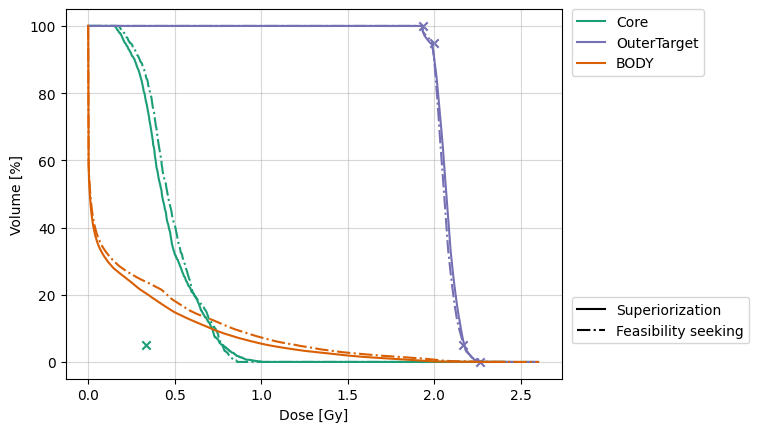

In [14]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02']

# a,b = calc_dvh(dij@sol.get(), new_idxs)

# for i,(el,label) in enumerate(zip(a,organs_c)):
#     plt.plot(b,el,color = colors[i],linestyle = '-.')
# plt.plot(0,0,label = r'Extrapolated Landweber', color = 'k', linestyle = '-.')
# plt.legend()

fig,ax = plt.subplots()

# a,b = calc_dvh(dij@sol_matRad*30, idxs)

# for i,(el,label) in enumerate(zip(a,labels)):
#     ax.plot(b,el*100,color = colors[i],linestyle = ':')

a,b = calc_dvh(dij@sol_cq_w_i.get(), idxs)
for i,(el,label) in enumerate(zip(a,labels)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')

# a,b = calc_dvh(dij@sol_sup_10.get(), idxs)
# for i,(el,label) in enumerate(zip(a,labels)):
#     ax.plot(b,el*100,color = colors[i],linestyle = '--')




a,b = calc_dvh(dij@sol_sup_w_i_low.get(), idxs)
handles = []
for i,(el,label) in enumerate(zip(a,labels)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)



p1 = ax.plot(0,0,label = r'Superiorization', color = 'k',linestyle = '-')
p2 = ax.plot(0,0,label = r'Feasibility seeking', color = 'k',linestyle = '-.')
#p3 = ax.plot(0,0,label = r'Optimization', color = 'k',linestyle = ':')
#p4 = ax.plot(0,0,label = r'Sup 10', color = 'k',linestyle = '--')

handles = [p1[0], p2[0]]#, p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

ax.add_artist(legend1)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



plt.scatter(10 / frac,5,marker = 'x',color = colors[0])
plt.scatter(68 / frac,0,marker = 'x',color = colors[1])
plt.scatter(58 / frac,100,marker = 'x',color = colors[1])
plt.scatter(65 / frac,5,marker = 'x',color = colors[1])
plt.scatter(60 / frac,95,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')

plt.grid(alpha = 0.5)

plt.savefig('TG_119_comparison_feasibility_seeking_vs_superiorization_30_fractions.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

In [15]:
# scipy.io.savemat('TG119_DVH_results_w_i_30_fractions.mat',{'sol_feasibility': sol_cq_w_i.get(),
#                                            'sol_sup_pert': sol_sup_w_i.get(),
#                                            'sol_sup_pert_low': sol_sup_w_i_low.get()})

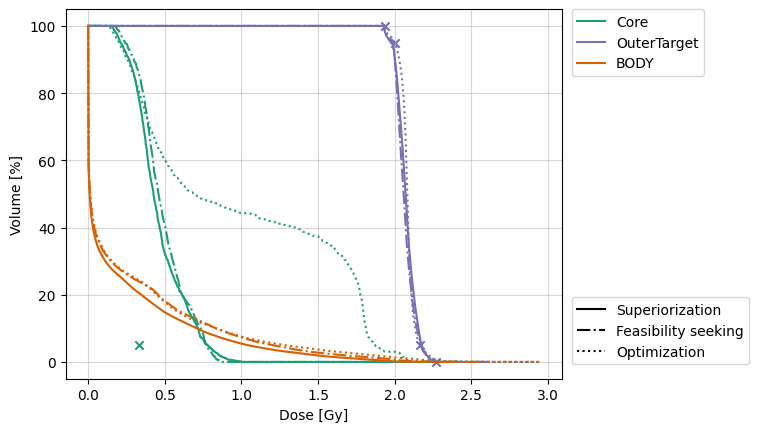

In [16]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02']

# a,b = calc_dvh(dij@sol.get(), new_idxs)

# for i,(el,label) in enumerate(zip(a,organs_c)):
#     plt.plot(b,el,color = colors[i],linestyle = '-.')
# plt.plot(0,0,label = r'Extrapolated Landweber', color = 'k', linestyle = '-.')
# plt.legend()

fig,ax = plt.subplots()

a,b = calc_dvh(dij@sol_matRad, idxs)

for i,(el,label) in enumerate(zip(a,labels)):
    ax.plot(b,el*100,color = colors[i],linestyle = ':')

a,b = calc_dvh(dij@sol_cq_w_i.get(), idxs)
for i,(el,label) in enumerate(zip(a,labels)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')

# a,b = calc_dvh(dij@sol_sup_10.get(), idxs)
# for i,(el,label) in enumerate(zip(a,labels)):
#     ax.plot(b,el*100,color = colors[i],linestyle = '--')




a,b = calc_dvh(dij@sol_sup_w_i_low.get(), idxs)
handles = []
for i,(el,label) in enumerate(zip(a,labels)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)



p1 = ax.plot(0,0,label = r'Superiorization', color = 'k',linestyle = '-')
p2 = ax.plot(0,0,label = r'Feasibility seeking', color = 'k',linestyle = '-.')
p3 = ax.plot(0,0,label = r'Optimization', color = 'k',linestyle = ':')
#p4 = ax.plot(0,0,label = r'Sup 10', color = 'k',linestyle = '--')

handles = [p1[0], p2[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

ax.add_artist(legend1)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



plt.scatter(10 / frac,5,marker = 'x',color = colors[0])
plt.scatter(68 / frac,0,marker = 'x',color = colors[1])
plt.scatter(58 / frac,100,marker = 'x',color = colors[1])
plt.scatter(65 / frac,5,marker = 'x',color = colors[1])
plt.scatter(60 / frac,95,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')

plt.grid(alpha = 0.5)

plt.savefig('TG_119_comparison_feasibility_seeking_vs_superiorization_vs_optimization(infeasible)_30_fractions.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

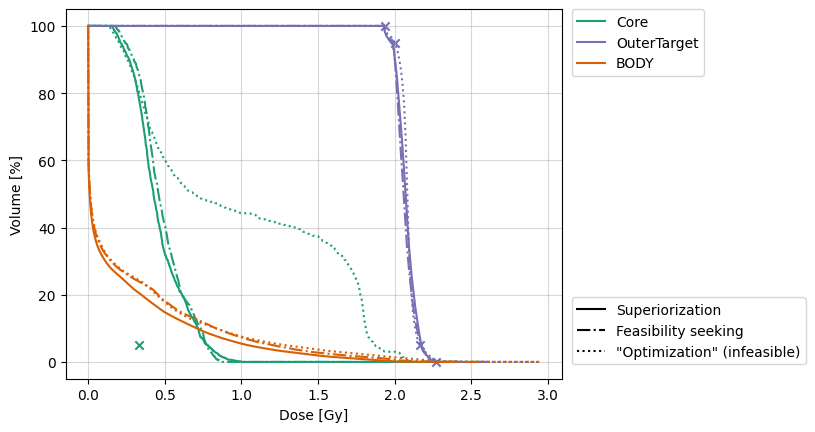

In [17]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02']

# a,b = calc_dvh(dij@sol.get(), new_idxs)

# for i,(el,label) in enumerate(zip(a,organs_c)):
#     plt.plot(b,el,color = colors[i],linestyle = '-.')
# plt.plot(0,0,label = r'Extrapolated Landweber', color = 'k', linestyle = '-.')
# plt.legend()

fig,ax = plt.subplots()

a,b = calc_dvh(dij@sol_matRad, idxs)

for i,(el,label) in enumerate(zip(a,labels)):
    ax.plot(b,el*100,color = colors[i],linestyle = ':')

a,b = calc_dvh(dij@sol_cq_w_i.get(), idxs)
for i,(el,label) in enumerate(zip(a,labels)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')

# a,b = calc_dvh(dij@sol_sup_10.get(), idxs)
# for i,(el,label) in enumerate(zip(a,labels)):
#     ax.plot(b,el*100,color = colors[i],linestyle = '--')




a,b = calc_dvh(dij@sol_sup_w_i_low.get(), idxs)
handles = []
for i,(el,label) in enumerate(zip(a,labels)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)



p1 = ax.plot(0,0,label = r'Superiorization', color = 'k',linestyle = '-')
p2 = ax.plot(0,0,label = r'Feasibility seeking', color = 'k',linestyle = '-.')
p3 = ax.plot(0,0,label = r'"Optimization" (infeasible)', color = 'k',linestyle = ':')
#p4 = ax.plot(0,0,label = r'Sup 10', color = 'k',linestyle = '--')

handles = [p1[0], p2[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

ax.add_artist(legend1)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



plt.scatter(10 / frac,5,marker = 'x',color = colors[0])
plt.scatter(68 / frac,0,marker = 'x',color = colors[1])
plt.scatter(58 / frac,100,marker = 'x',color = colors[1])
plt.scatter(65 / frac,5,marker = 'x',color = colors[1])
plt.scatter(60 / frac,95,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')

plt.grid(alpha = 0.5)

plt.savefig('TG_119_comparison_feasibility_seeking_vs_superiorization_vs_optimization(infeasible)_30_fractions_2.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

'#666666'